# CECS 551 – Complete Project Notebook
**Project:** Deep Learning-Based Automated Detection of Cardiac Arrhythmia from ECG Signals  
**Team:** Leela Prasad Reddy Surasani · Mohan Sai Teja Chebrolu · Jashwanth Adapureddi  
**Department:** Computer Engineering and Computer Science, California State University Long Beach  
**Dataset:** ECG Heartbeat Categorization (Kaggle: shayanfazeli/heartbeat) — derived from MIT-BIH Arrhythmia Database  

---

## Table of Contents
### Phase 3 — Preliminary EDA
1. Setup & Data Loading
2. Basic Data Inspection
3. Class Distribution Analysis
4. Sample ECG Waveform Visualization Per Class
5. Zero-Padding Detection
6. Statistical Feature Summary
7. Mean Waveform Per Class
8. SMOTE Preview
9. EDA Findings Summary

### Phase 4 — Model Training & Evaluation
10. Preprocessing Pipeline
11. Feature Extraction (for Random Forest)
12. Model 1 — Random Forest Baseline
13. Model 2 — 1D CNN
14. Model 3 — Hybrid CNN-LSTM
15. Comparative Evaluation
16. Final Results Summary

---
# PHASE 3 — Preliminary Exploratory Data Analysis

## 1. Setup & Data Loading

In [ ]:
# Install all required libraries
!pip install -q imbalanced-learn scikit-learn pandas numpy matplotlib seaborn tensorflow scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import json
warnings.filterwarnings('ignore')

# Reproducibility — fixed seed for all operations
SEED = 42
np.random.seed(SEED)

from collections import Counter
from scipy.stats import skew, kurtosis

# Class label mapping
CLASS_LABELS = {
    0: 'Normal (N)',
    1: 'Supraventricular\nEctopic (S)',
    2: 'Ventricular\nEctopic (V)',
    3: 'Fusion Beat (F)',
    4: 'Unknown/Paced (Q)'
}
CLASS_NAMES  = [CLASS_LABELS[i].replace('\n', ' ') for i in range(5)]
CLASS_COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
N_CLASSES    = 5

print('Libraries loaded. SEED =', SEED)

Libraries loaded. SEED = 42


In [ ]:
# Mount Google Drive (files stored in MyDrive/CECS551/)
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = '/content/drive/MyDrive/CECS551/mitbih_train.csv'
TEST_PATH  = '/content/drive/MyDrive/CECS551/mitbih_test.csv'

train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df  = pd.read_csv(TEST_PATH,  header=None)

X_train_raw = train_df.iloc[:, :-1].values
y_train_raw = train_df.iloc[:, -1].values.astype(int)
X_test      = test_df.iloc[:, :-1].values
y_test      = test_df.iloc[:, -1].values.astype(int)

print(f'Training samples : {X_train_raw.shape[0]:,}  |  Features per sample: {X_train_raw.shape[1]}')
print(f'Test samples     : {X_test.shape[0]:,}  |  Features per sample: {X_test.shape[1]}')

Mounted at /content/drive
Training samples : 87,554  |  Features per sample: 187
Test samples     : 21,892  |  Features per sample: 187


## 2. Basic Data Inspection

In [ ]:
print('=== Missing Values ===')
print(f'Train missing: {train_df.isnull().sum().sum()}')
print(f'Test missing : {test_df.isnull().sum().sum()}')

print('\n=== Amplitude Range ===')
print(f'Train min: {X_train_raw.min():.4f}  max: {X_train_raw.max():.4f}')
print(f'Test  min: {X_test.min():.4f}  max: {X_test.max():.4f}')

print('\n=== Sample Shape ===')
print('Each heartbeat is a 187-sample time series (1D window), pre-normalized to [0, 1].')

=== Missing Values ===
Train missing: 0
Test missing : 0

=== Amplitude Range ===
Train min: 0.0000  max: 1.0000
Test  min: 0.0000  max: 1.0000

=== Sample Shape ===
Each heartbeat is a 187-sample time series (1D window), pre-normalized to [0, 1].


## 3. Class Distribution Analysis

Class Distribution — Training Set
Class  Label                               Count  % Train
------------------------------------------------------------
0      Normal (N)                         72,471    82.8%
1      Supraventricular Ectopic (S)        2,223     2.5%
2      Ventricular Ectopic (V)             5,788     6.6%
3      Fusion Beat (F)                       641     0.7%
4      Unknown/Paced (Q)                   6,431     7.3%


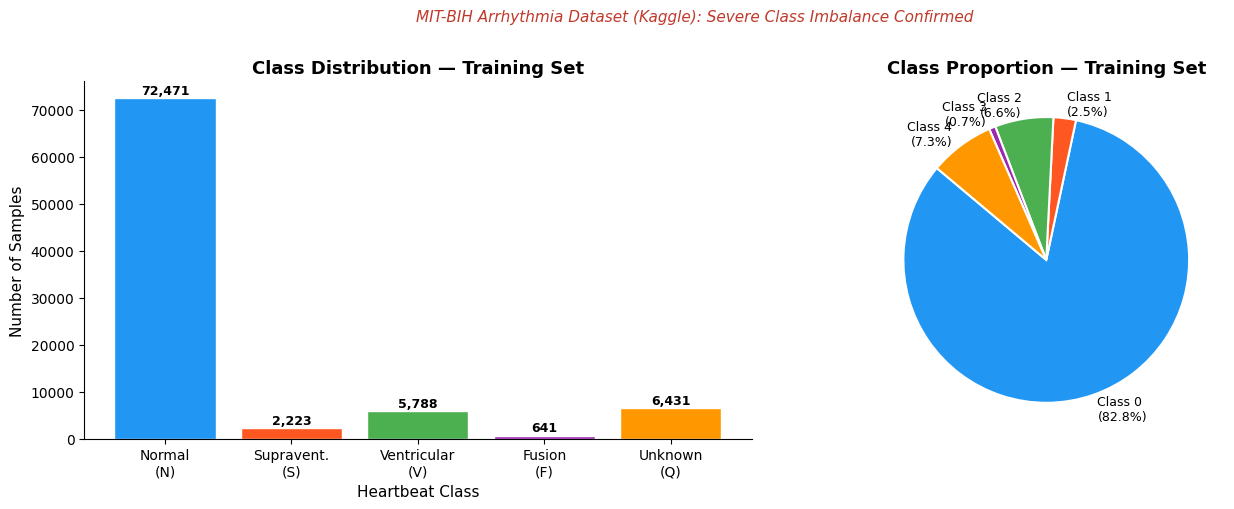

Saved: class_distribution.png


In [ ]:
train_counts = Counter(y_train_raw)
test_counts  = Counter(y_test)

print('Class Distribution — Training Set')
print(f'{"Class":<6} {"Label":<32} {"Count":>8} {"% Train":>8}')
print('-' * 60)
for c in sorted(train_counts):
    pct   = train_counts[c] / len(y_train_raw) * 100
    label = CLASS_LABELS[c].replace('\n', ' ')
    print(f'{c:<6} {label:<32} {train_counts[c]:>8,} {pct:>7.1f}%')

# Bar + Pie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(train_counts.keys())
counts  = [train_counts[c] for c in classes]
xlabels = ['Normal\n(N)', 'Supravent.\n(S)', 'Ventricular\n(V)', 'Fusion\n(F)', 'Unknown\n(Q)']

bars = axes[0].bar(xlabels, counts, color=CLASS_COLORS, edgecolor='white')
axes[0].set_title('Class Distribution — Training Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_xlabel('Heartbeat Class', fontsize=11)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

pie_labels = [f'Class {c}\n({train_counts[c]/len(y_train_raw)*100:.1f}%)' for c in classes]
axes[1].pie(counts, labels=pie_labels, colors=CLASS_COLORS, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, textprops={'fontsize': 9})
axes[1].set_title('Class Proportion — Training Set', fontsize=13, fontweight='bold')

plt.suptitle('MIT-BIH Arrhythmia Dataset (Kaggle): Severe Class Imbalance Confirmed',
             fontsize=11, color='#c0392b', y=1.01, style='italic')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

## 4. Sample ECG Waveform Visualization Per Class

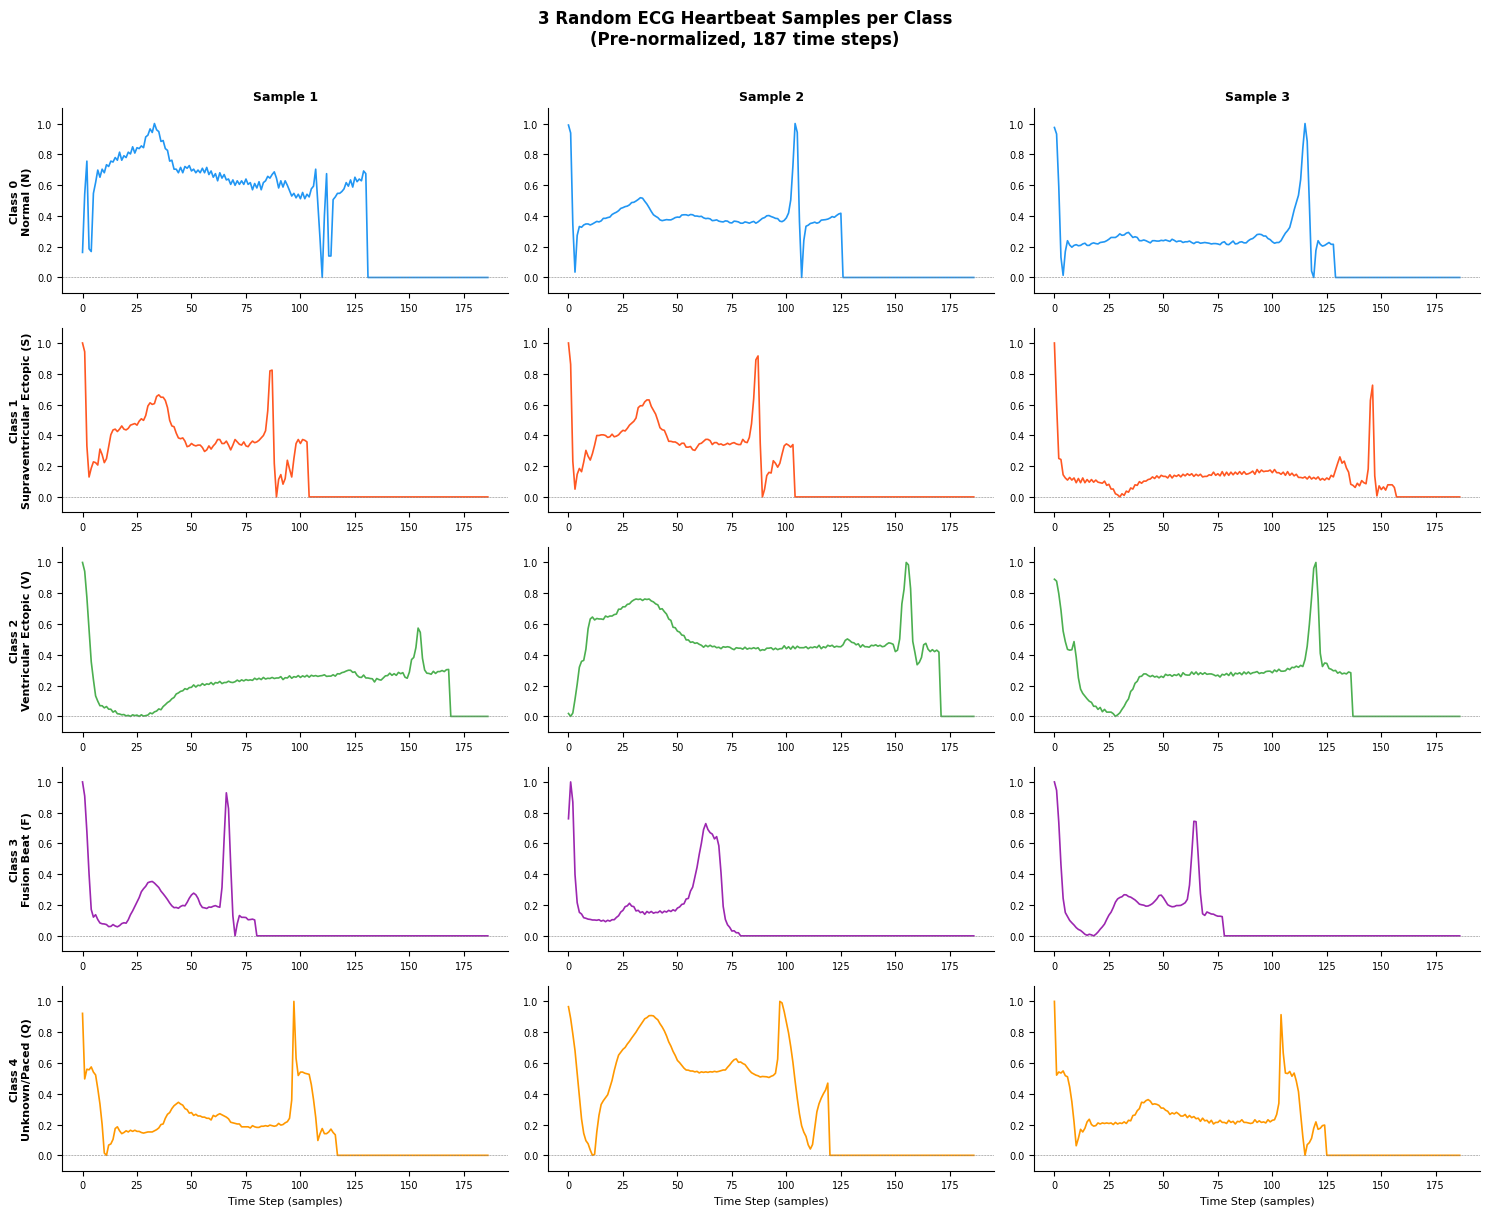

Saved: ecg_waveforms_per_class.png


In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(15, 12))
time_axis = np.arange(187)

for class_idx in range(5):
    samples_idx = np.where(y_train_raw == class_idx)[0]
    chosen = np.random.choice(samples_idx, 3, replace=False)
    for j, idx in enumerate(chosen):
        ax = axes[class_idx][j]
        ax.plot(time_axis, X_train_raw[idx], color=CLASS_COLORS[class_idx], linewidth=1.2)
        ax.set_ylim(-0.1, 1.1)
        ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=7)
        if j == 0:
            short = CLASS_LABELS[class_idx].replace('\n', ' ')
            ax.set_ylabel(f'Class {class_idx}\n{short}', fontsize=8, fontweight='bold')
        if class_idx == 0:
            ax.set_title(f'Sample {j+1}', fontsize=9, fontweight='bold')
        if class_idx == 4:
            ax.set_xlabel('Time Step (samples)', fontsize=8)

plt.suptitle('3 Random ECG Heartbeat Samples per Class\n(Pre-normalized, 187 time steps)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ecg_waveforms_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ecg_waveforms_per_class.png')

## 5. Zero-Padding Detection

In [ ]:
def count_trailing_zeros(signal, threshold=10):
    trailing = 0
    for val in reversed(signal):
        if val == 0.0:
            trailing += 1
        else:
            break
    return trailing >= threshold

padded_mask = np.array([count_trailing_zeros(X_train_raw[i]) for i in range(len(X_train_raw))])
n_padded    = padded_mask.sum()
pct_padded  = n_padded / len(X_train_raw) * 100

print(f'Samples with >10 trailing zeros: {n_padded:,} ({pct_padded:.1f}% of training set)')
print('\nPadding breakdown by class:')
for c in range(5):
    class_mask  = (y_train_raw == c)
    n_pad_class = (padded_mask & class_mask).sum()
    pct         = n_pad_class / class_mask.sum() * 100
    label       = CLASS_LABELS[c].replace('\n', ' ')
    print(f'  Class {c} ({label}): {n_pad_class:,} padded ({pct:.1f}%)')

Samples with >10 trailing zeros: 86,048 (98.3% of training set)

Padding breakdown by class:
  Class 0 (Normal (N)): 71,696 padded (98.9%)
  Class 1 (Supraventricular Ectopic (S)): 1,930 padded (86.8%)
  Class 2 (Ventricular Ectopic (V)): 5,352 padded (92.5%)
  Class 3 (Fusion Beat (F)): 640 padded (99.8%)
  Class 4 (Unknown/Paced (Q)): 6,430 padded (100.0%)


## 6. Statistical Feature Summary

Mean feature values per class (first 6 features):
           Mean     Std     Min     Max   Range  Skewness
Class 0  0.1619  0.1861  0.0000  1.0000  1.0000    2.3648
Class 1  0.1948  0.1868  0.0012  0.9919  0.9908    1.7842
Class 2  0.2438  0.2290  0.0000  0.9995  0.9995    1.1899
Class 3  0.1073  0.1813  0.0000  1.0000  1.0000    2.6835
Class 4  0.2509  0.2412  0.0000  1.0000  1.0000    0.8221


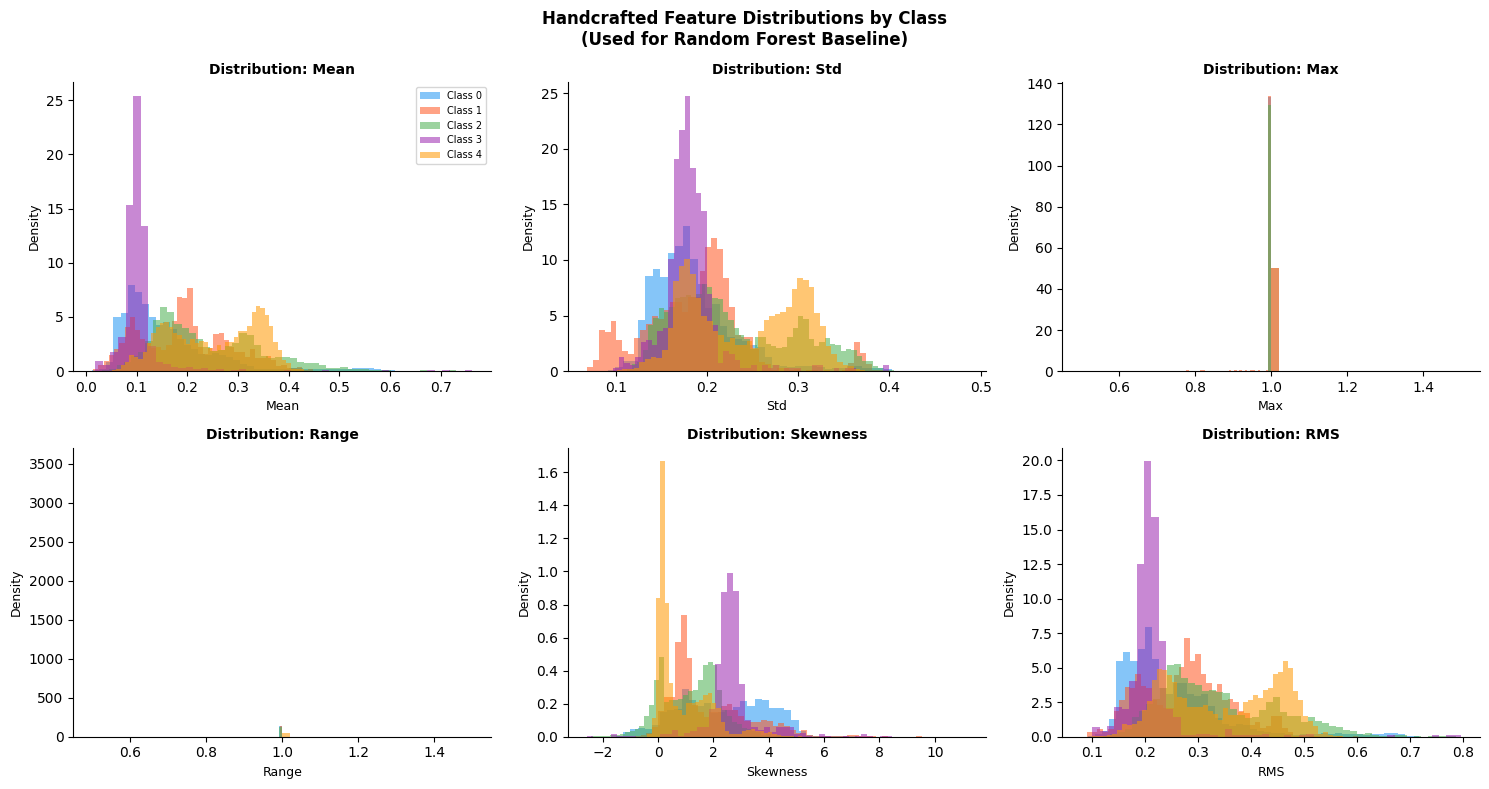

Saved: feature_distributions.png


In [ ]:
def extract_features(X):
    return np.column_stack([
        X.mean(axis=1),
        X.std(axis=1),
        X.min(axis=1),
        X.max(axis=1),
        X.max(axis=1) - X.min(axis=1),
        skew(X, axis=1),
        kurtosis(X, axis=1),
        np.sqrt((X**2).mean(axis=1)),
        ((X[:, 1:] * X[:, :-1]) < 0).sum(axis=1),
        X.max(axis=1),
    ])

feat_names  = ['Mean', 'Std', 'Min', 'Max', 'Range', 'Skewness', 'Kurtosis', 'RMS', 'ZCR', 'Peak']
feat_matrix = extract_features(X_train_raw)
feat_df     = pd.DataFrame(feat_matrix, columns=feat_names)
feat_df['Class'] = y_train_raw

summary = feat_df.groupby('Class')[feat_names[:6]].mean().round(4)
summary.index = [f'Class {i}' for i in summary.index]
print('Mean feature values per class (first 6 features):')
print(summary.to_string())

# Feature distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
plot_feats = ['Mean', 'Std', 'Max', 'Range', 'Skewness', 'RMS']

for i, feat in enumerate(plot_feats):
    for c in range(5):
        vals = feat_df[feat_df['Class'] == c][feat]
        axes[i].hist(vals, bins=50, alpha=0.55, color=CLASS_COLORS[c],
                     label=f'Class {c}', density=True)
    axes[i].set_title(f'Distribution: {feat}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    if i == 0:
        axes[i].legend(fontsize=7, loc='upper right')

plt.suptitle('Handcrafted Feature Distributions by Class\n(Used for Random Forest Baseline)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

## 7. Mean Waveform Per Class

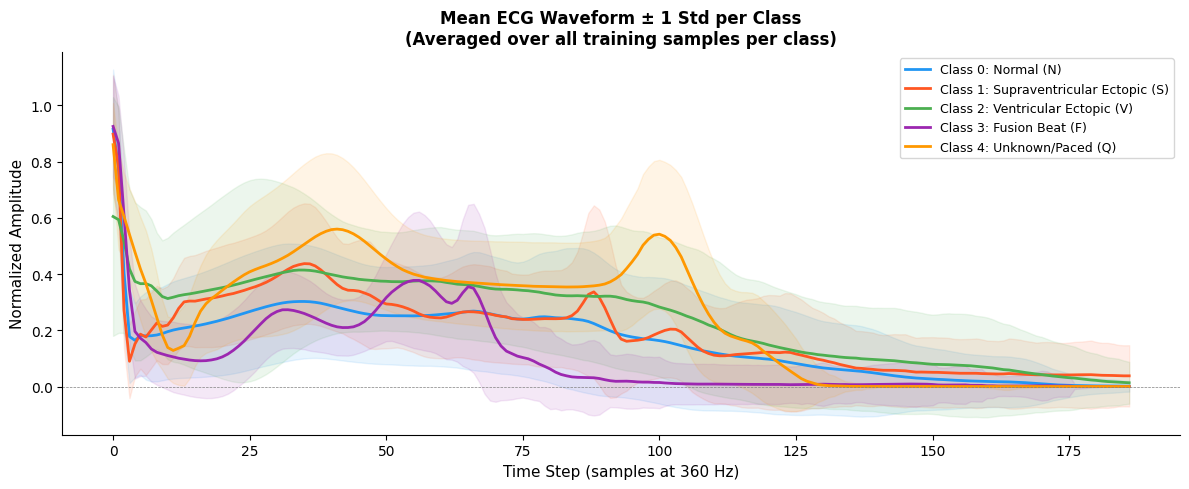

Saved: mean_waveforms_per_class.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
time_axis = np.arange(187)

for c in range(5):
    class_signals = X_train_raw[y_train_raw == c]
    mean_signal   = class_signals.mean(axis=0)
    std_signal    = class_signals.std(axis=0)
    label         = CLASS_LABELS[c].replace('\n', ' ')
    ax.plot(time_axis, mean_signal, color=CLASS_COLORS[c], linewidth=2, label=f'Class {c}: {label}')
    ax.fill_between(time_axis, mean_signal - std_signal, mean_signal + std_signal,
                    color=CLASS_COLORS[c], alpha=0.1)

ax.set_title('Mean ECG Waveform ± 1 Std per Class\n(Averaged over all training samples per class)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Time Step (samples at 360 Hz)', fontsize=11)
ax.set_ylabel('Normalized Amplitude', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('mean_waveforms_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mean_waveforms_per_class.png')

## 8. SMOTE Preview — Post-Resampling Class Distribution

Post-resampling class counts:
  Class 0 (Normal (N)): 10,000 (28.4%)
  Class 1 (Supraventricular Ectopic (S)): 6,500 (18.5%)
  Class 2 (Ventricular Ectopic (V)): 5,788 (16.4%)
  Class 3 (Fusion Beat (F)): 6,500 (18.5%)
  Class 4 (Unknown/Paced (Q)): 6,431 (18.3%)
  Total: 35,219 samples


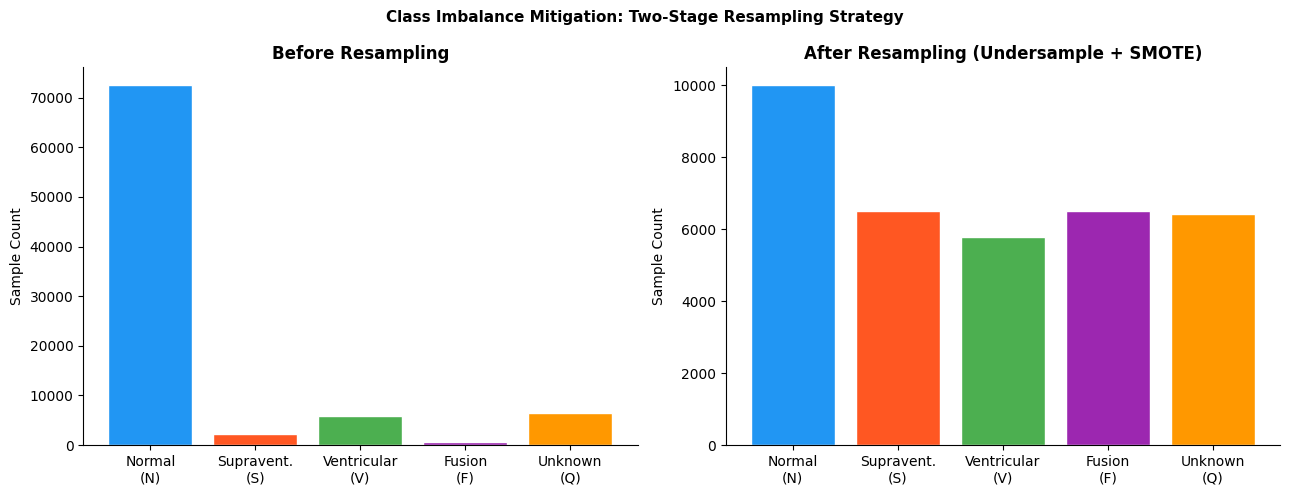

Saved: smote_comparison.png


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# SMOTE targets must exceed existing class counts
# Class 1: 2,223 → 6,500  |  Class 3: 641 → 6,500
# Classes 2 & 4 already sufficient, excluded from SMOTE
undersample_strategy = {0: 10000}
oversample_strategy  = {1: 6500, 3: 6500}

preview_pipeline = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=SEED)),
    ('over',  SMOTE(sampling_strategy=oversample_strategy, k_neighbors=5, random_state=SEED))
])

X_preview, y_preview = preview_pipeline.fit_resample(X_train_raw, y_train_raw)

print('Post-resampling class counts:')
res_counts = Counter(y_preview)
for c in sorted(res_counts):
    label = CLASS_LABELS[c].replace('\n', ' ')
    pct   = res_counts[c] / len(y_preview) * 100
    print(f'  Class {c} ({label}): {res_counts[c]:,} ({pct:.1f}%)')
print(f'  Total: {len(y_preview):,} samples')

# Before / After comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xlabels = ['Normal\n(N)', 'Supravent.\n(S)', 'Ventricular\n(V)', 'Fusion\n(F)', 'Unknown\n(Q)']
orig_counts = [train_counts[c] for c in range(5)]
new_counts  = [res_counts[c]   for c in range(5)]

axes[0].bar(xlabels, orig_counts, color=CLASS_COLORS, edgecolor='white')
axes[0].set_title('Before Resampling', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].bar(xlabels, new_counts, color=CLASS_COLORS, edgecolor='white')
axes[1].set_title('After Resampling (Undersample + SMOTE)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sample Count')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Class Imbalance Mitigation: Two-Stage Resampling Strategy',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: smote_comparison.png')

## 9. EDA Findings Summary

| Finding | Impact on Pipeline |
|---|---|
| Severe class imbalance (Class 0 = 82.8%) | Two-stage SMOTE + class-weighted loss mandatory |
| No missing values | No imputation needed |
| Pre-normalized [0, 1] range | Z-score normalization applied per-sample in Phase 4 |
| Zero-padded samples (~98%) | Retained; effect monitored during training |
| Morphologically distinct class waveforms | CNN morphological extraction well-justified |
| Pre-defined train/test split available | Used as-is for benchmark comparability |

**Next:** Phase 4 — Model Training & Evaluation

---
# PHASE 4 — Model Training & Evaluation

## 10. Preprocessing Pipeline

In [ ]:
import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, f1_score, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    LSTM, Dense, Dropout, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print('Phase 4 libraries loaded. TF version:', tf.__version__)

Phase 4 libraries loaded. TF version: 2.20.0


In [ ]:
# ── Z-score normalization per sample ──────────────────────────
def zscore_normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mean) / std

X_train_norm = zscore_normalize(X_train_raw)
X_test_norm  = zscore_normalize(X_test)
print('Z-score normalization complete.')

# ── Two-stage resampling (training set only) ──────────────────
resample_pipeline = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy={0: 10000}, random_state=SEED)),
    ('over',  SMOTE(sampling_strategy={1: 6500, 3: 6500}, k_neighbors=5, random_state=SEED))
])

X_train_res, y_train_res = resample_pipeline.fit_resample(X_train_norm, y_train_raw)
print('Post-resampling distribution:', Counter(y_train_res))
print(f'Total resampled training samples: {len(y_train_res):,}')

# ── Stratified validation split (15%) ─────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res,
    test_size=0.15, random_state=SEED, stratify=y_train_res
)
print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_test_norm.shape}')

# ── Class weights ─────────────────────────────────────────────
class_weights_arr = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr)
class_weight_dict = {i: class_weights_arr[i] for i in range(N_CLASSES)}
print('Class weights:', {k: round(v, 3) for k, v in class_weight_dict.items()})

# ── Binarize test labels for AUROC ────────────────────────────
y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))

Z-score normalization complete.
Post-resampling distribution: Counter({np.int64(0): 10000, np.int64(1): 6500, np.int64(3): 6500, np.int64(4): 6431, np.int64(2): 5788})
Total resampled training samples: 35,219
Train: (29936, 187) | Val: (5283, 187) | Test: (21892, 187)
Class weights: {0: np.float64(0.704), 1: np.float64(1.084), 2: np.float64(1.217), 3: np.float64(1.084), 4: np.float64(1.095)}


## 11. Feature Extraction (for Random Forest)

In [ ]:
X_tr_feat   = extract_features(X_tr)
X_val_feat  = extract_features(X_val)
X_test_feat = extract_features(X_test_norm)
print(f'Feature matrix: {X_tr_feat.shape}  (10 handcrafted features per sample)')

Feature matrix: (29936, 10)  (10 handcrafted features per sample)


## 12. Model 1 — Random Forest Baseline

In [ ]:
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_model.fit(X_tr_feat, y_tr)
print('Done.')

y_pred_rf = rf_model.predict(X_test_feat)
y_prob_rf = rf_model.predict_proba(X_test_feat)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='macro')
rf_auc = roc_auc_score(y_test_bin, y_prob_rf, multi_class='ovr', average='macro')

print(f'\n=== Random Forest Results ===')
print(f'Accuracy    : {rf_acc:.4f}')
print(f'Macro F1    : {rf_f1:.4f}')
print(f'Macro AUROC : {rf_auc:.4f}')
print('\nPer-class Report:')
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

Training Random Forest...
Done.

=== Random Forest Results ===
Accuracy    : 0.8627
Macro F1    : 0.6368
Macro AUROC : 0.9372

Per-class Report:
                              precision    recall  f1-score   support

                  Normal (N)       0.96      0.88      0.92     18118
Supraventricular Ectopic (S)       0.36      0.53      0.43       556
     Ventricular Ectopic (V)       0.52      0.79      0.63      1448
             Fusion Beat (F)       0.37      0.57      0.45       162
           Unknown/Paced (Q)       0.67      0.86      0.75      1608

                    accuracy                           0.86     21892
                   macro avg       0.58      0.73      0.64     21892
                weighted avg       0.89      0.86      0.87     21892



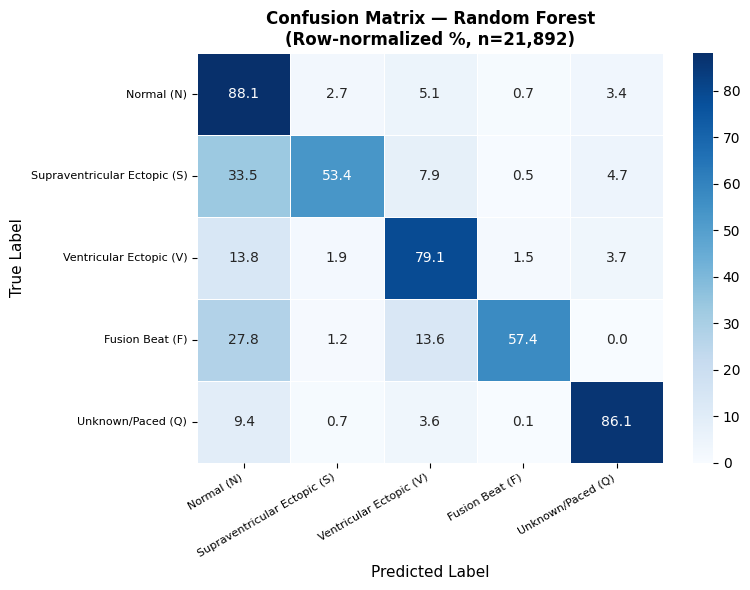

Saved: cm_rf.png


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(f'{title}\n(Row-normalized %, n={len(y_true):,})', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

plot_confusion_matrix(y_test, y_pred_rf, 'Confusion Matrix — Random Forest', 'cm_rf.png')

## 13. Model 2 — 1D Convolutional Neural Network (CNN)

In [ ]:
# Reshape inputs for CNN: (samples, timesteps, 1)
X_tr_cnn   = X_tr.reshape(-1, 187, 1)
X_val_cnn  = X_val.reshape(-1, 187, 1)
X_test_cnn = X_test_norm.reshape(-1, 187, 1)

def build_cnn(input_length=187, n_classes=5):
    model = Sequential([
        Input(shape=(input_length, 1)),
        Conv1D(64,  kernel_size=5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        GlobalAveragePooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(n_classes, activation='softmax')
    ], name='CNN_1D')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,189 (614.02 KB)

 Trainable params: 157,189 (614.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print('Training 1D CNN...')
history_cnn = cnn_model.fit(
    X_tr_cnn, y_tr,
    validation_data=(X_val_cnn, y_val),
    epochs=50, batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint('best_cnn.h5', monitor='val_loss', save_best_only=True, verbose=0)
    ],
    verbose=1
)
print('CNN training complete.')

Training 1D CNN...
Epoch 1/50
467/468 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5158 - loss: 1.1427

468/468 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.6445 - loss: 0.8704 - val_accuracy: 0.8047 - val_loss: 0.5575
Epoch 2/50
467/468 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7847 - loss: 0.5440

468/468 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - accuracy: 0.8077 - loss: 0.4984 - val_accuracy: 0.8522 - val_loss: 0.4206
Epoch 3/50
467/468 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8359 - loss: 0.4313

468/468 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.8475 - loss: 0.4074 - val_accuracy: 0.8730 - val_loss: 0.3719
Epoch 4/50
467/468 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8613 - loss: 0.3747

468/468 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.8690 - loss: 0.3572 - val_accuracy: 0.8830 - val_loss: 0.3221
Epoch 5/50
467/468 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8778 - loss: 0.3325

...

468/468 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.9574 - loss: 0.1117 - val_accuracy: 0.9608 - val_loss: 0.1212
Epoch 29/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9601 - loss: 0.1073 - val_accuracy: 0.9580 - val_loss: 0.1259
Epoch 30/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9607 - loss: 0.1058

468/468 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - accuracy: 0.9609 - loss: 0.1035 - val_accuracy: 0.9614 - val_loss: 0.1211
Epoch 31/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9607 - loss: 0.1028

468/468 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.9625 - loss: 0.0980 - val_accuracy: 0.9621 - val_loss: 0.1171
Epoch 32/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9633 - loss: 0.0983

468/468 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9632 - loss: 0.0995 - val_accuracy: 0.9648 - val_loss: 0.1149
Epoch 33/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - accuracy: 0.9625 - loss: 0.0954 - val_accuracy: 0.9627 - val_loss: 0.1247
Epoch 34/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9654 - loss: 0.0889

468/468 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.9652 - loss: 0.0886 - val_accuracy: 0.9642 - val_loss: 0.1127
Epoch 35/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.9661 - loss: 0.0874 - val_accuracy: 0.9635 - val_loss: 0.1136
Epoch 36/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - accuracy: 0.9665 - loss: 0.0862 - val_accuracy: 0.9633 - val_loss: 0.1227
Epoch 37/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9667 - loss: 0.0835 - val_accuracy: 0.9593 - val_loss: 0.1278
Epoch 38/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.9676 - loss: 0.0822 - val_accuracy: 0.9593 - val_loss: 0.1231
Epoch 39/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.9683 - loss: 0.0809 - val_accuracy: 0.9597 - val_loss: 0.1196
Epoch 40/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.9697 - loss: 0.0746 - val_accuracy: 0.9606 - val_loss: 0.1196
Epoch 41/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9718 - loss: 0.0712 - val_

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step

=== 1D CNN Results ===
Accuracy    : 0.9555
Macro F1    : 0.8223
Macro AUROC : 0.9876

Per-class Report:
                              precision    recall  f1-score   support

                  Normal (N)       0.99      0.96      0.98     18118
Supraventricular Ectopic (S)       0.58      0.78      0.67       556
     Ventricular Ectopic (V)       0.82      0.96      0.88      1448
             Fusion Beat (F)       0.46      0.90      0.61       162
           Unknown/Paced (Q)       0.96      0.99      0.97      1608

                    accuracy                           0.96     21892
                   macro avg       0.76      0.92      0.82     21892
                weighted avg       0.96      0.96      0.96     21892



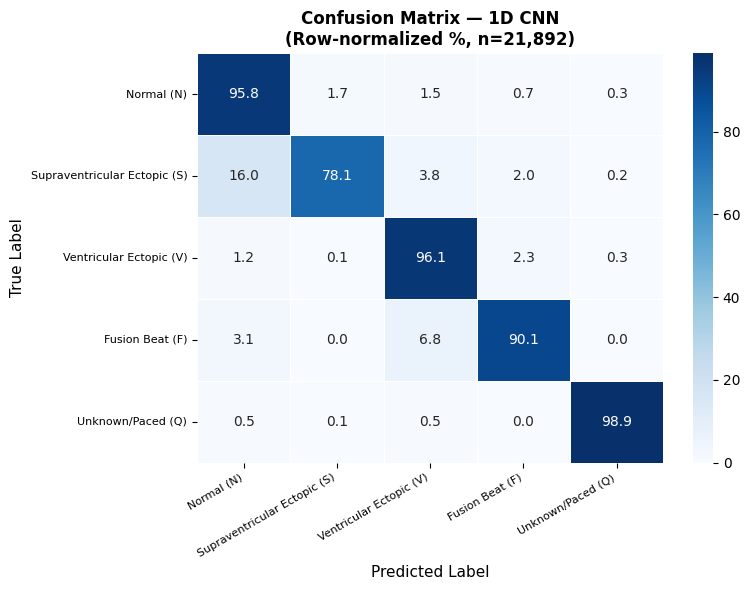

Saved: cm_cnn.png


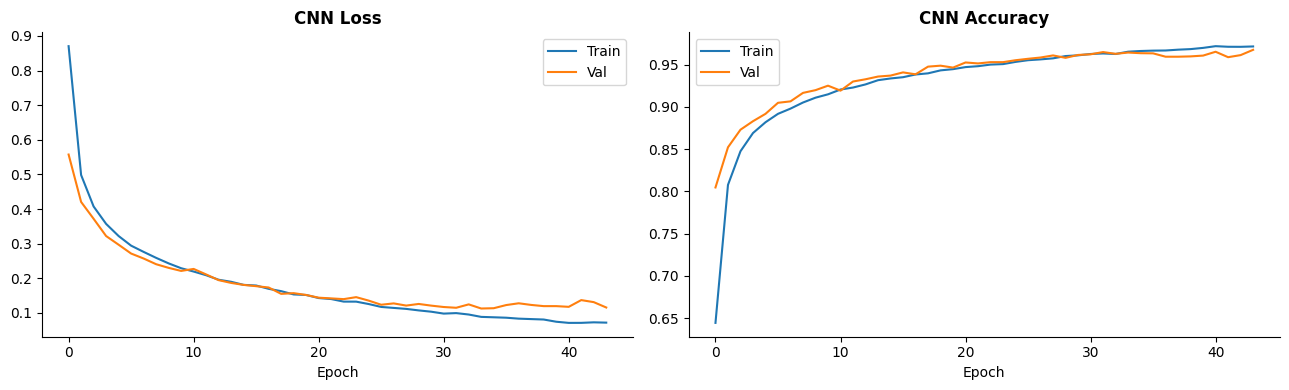

Saved: training_curves_cnn.png


In [ ]:
y_prob_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = y_prob_cnn.argmax(axis=1)

cnn_acc = accuracy_score(y_test, y_pred_cnn)
cnn_f1  = f1_score(y_test, y_pred_cnn, average='macro')
cnn_auc = roc_auc_score(y_test_bin, y_prob_cnn, multi_class='ovr', average='macro')

print(f'\n=== 1D CNN Results ===')
print(f'Accuracy    : {cnn_acc:.4f}')
print(f'Macro F1    : {cnn_f1:.4f}')
print(f'Macro AUROC : {cnn_auc:.4f}')
print('\nPer-class Report:')
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))

plot_confusion_matrix(y_test, y_pred_cnn, 'Confusion Matrix — 1D CNN', 'cm_cnn.png')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_cnn.history['loss'], label='Train'); axes[0].plot(history_cnn.history['val_loss'], label='Val')
axes[0].set_title('CNN Loss', fontweight='bold'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
axes[1].plot(history_cnn.history['accuracy'], label='Train'); axes[1].plot(history_cnn.history['val_accuracy'], label='Val')
axes[1].set_title('CNN Accuracy', fontweight='bold'); axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('training_curves_cnn.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: training_curves_cnn.png')

## 14. Model 3 — Hybrid CNN-LSTM

In [ ]:
def build_cnn_lstm(input_length=187, n_classes=5):
    inputs = Input(shape=(input_length, 1))
    x = Conv1D(64,  kernel_size=5, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = LSTM(64, return_sequences=False)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    model = Model(inputs, outputs, name='CNN_LSTM')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_lstm_model = build_cnn_lstm()
cnn_lstm_model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 187, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 93, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,981 (308.52 KB)

 Trainable params: 78,981 (308.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print('Training CNN-LSTM...')
history_lstm = cnn_lstm_model.fit(
    X_tr_cnn, y_tr,
    validation_data=(X_val_cnn, y_val),
    epochs=50, batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint('best_cnn_lstm.h5', monitor='val_loss', save_best_only=True, verbose=0)
    ],
    verbose=1
)
print('CNN-LSTM training complete.')

Training CNN-LSTM...
Epoch 1/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4427 - loss: 1.2772

468/468 ━━━━━━━━━━━━━━━━━━━━ 47s 95ms/step - accuracy: 0.5531 - loss: 1.0759 - val_accuracy: 0.7252 - val_loss: 0.7369
Epoch 2/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7459 - loss: 0.6611

468/468 ━━━━━━━━━━━━━━━━━━━━ 81s 94ms/step - accuracy: 0.7734 - loss: 0.5913 - val_accuracy: 0.8137 - val_loss: 0.5240
Epoch 3/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8194 - loss: 0.4882

468/468 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.8318 - loss: 0.4529 - val_accuracy: 0.8673 - val_loss: 0.3750
Epoch 4/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8530 - loss: 0.3955

468/468 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.8620 - loss: 0.3704 - val_accuracy: 0.8758 - val_loss: 0.3530
Epoch 5/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8733 - loss: 0.3406

...

468/468 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.9650 - loss: 0.0943 - val_accuracy: 0.9616 - val_loss: 0.1256
Epoch 27/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.9655 - loss: 0.0920 - val_accuracy: 0.9589 - val_loss: 0.1433
Epoch 28/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.9639 - loss: 0.0995 - val_accuracy: 0.9620 - val_loss: 0.1283
Epoch 29/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9682 - loss: 0.0867 - val_accuracy: 0.9542 - val_loss: 0.1441
Epoch 30/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9656 - loss: 0.0897 - val_accuracy: 0.9559 - val_loss: 0.1416
Epoch 31/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9699 - loss: 0.0780 - val_accuracy: 0.9604 - val_loss: 0.1357
Epoch 32/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9698 - loss: 0.0804

468/468 ━━━━━━━━━━━━━━━━━━━━ 93s 115ms/step - accuracy: 0.9717 - loss: 0.0764 - val_accuracy: 0.9644 - val_loss: 0.1198
Epoch 33/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.9711 - loss: 0.0750 - val_accuracy: 0.9602 - val_loss: 0.1298
Epoch 34/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9736 - loss: 0.0718 - val_accuracy: 0.9625 - val_loss: 0.1290
Epoch 35/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9692 - loss: 0.0835

468/468 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9707 - loss: 0.0803 - val_accuracy: 0.9669 - val_loss: 0.1165
Epoch 36/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - accuracy: 0.9764 - loss: 0.0652 - val_accuracy: 0.9623 - val_loss: 0.1253
Epoch 37/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.9768 - loss: 0.0608 - val_accuracy: 0.9576 - val_loss: 0.1469
Epoch 38/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.9749 - loss: 0.0694 - val_accuracy: 0.9671 - val_loss: 0.1204
Epoch 39/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9755 - loss: 0.0671

468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9740 - loss: 0.0721 - val_accuracy: 0.9640 - val_loss: 0.1157
Epoch 40/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9766 - loss: 0.0630 - val_accuracy: 0.9669 - val_loss: 0.1202
Epoch 41/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 84s 93ms/step - accuracy: 0.9782 - loss: 0.0610 - val_accuracy: 0.9665 - val_loss: 0.1176
Epoch 42/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.9786 - loss: 0.0553 - val_accuracy: 0.9616 - val_loss: 0.1362
Epoch 43/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9803 - loss: 0.0534 - val_accuracy: 0.9627 - val_loss: 0.1263
Epoch 44/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9761 - loss: 0.0642 - val_accuracy: 0.9642 - val_loss: 0.1290
Epoch 45/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.9809 - loss: 0.0517 - val_accuracy: 0.9582 - val_loss: 0.1527
Epoch 46/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9806 - loss: 0.0536 - val_

468/468 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.9812 - loss: 0.0517 - val_accuracy: 0.9714 - val_loss: 0.1155
Epoch 49/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.9828 - loss: 0.0476 - val_accuracy: 0.9614 - val_loss: 0.1307
Epoch 50/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.9815 - loss: 0.0513 - val_accuracy: 0.9720 - val_loss: 0.1232
Restoring model weights from the end of the best epoch: 48.
CNN-LSTM training complete.


685/685 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step

=== CNN-LSTM Results ===
Accuracy    : 0.9420
Macro F1    : 0.7866
Macro AUROC : 0.9887

Per-class Report:
                              precision    recall  f1-score   support

                  Normal (N)       0.99      0.94      0.97     18118
Supraventricular Ectopic (S)       0.43      0.85      0.57       556
     Ventricular Ectopic (V)       0.86      0.95      0.90      1448
             Fusion Beat (F)       0.38      0.87      0.52       162
           Unknown/Paced (Q)       0.95      0.99      0.97      1608

                    accuracy                           0.94     21892
                   macro avg       0.72      0.92      0.79     21892
                weighted avg       0.96      0.94      0.95     21892



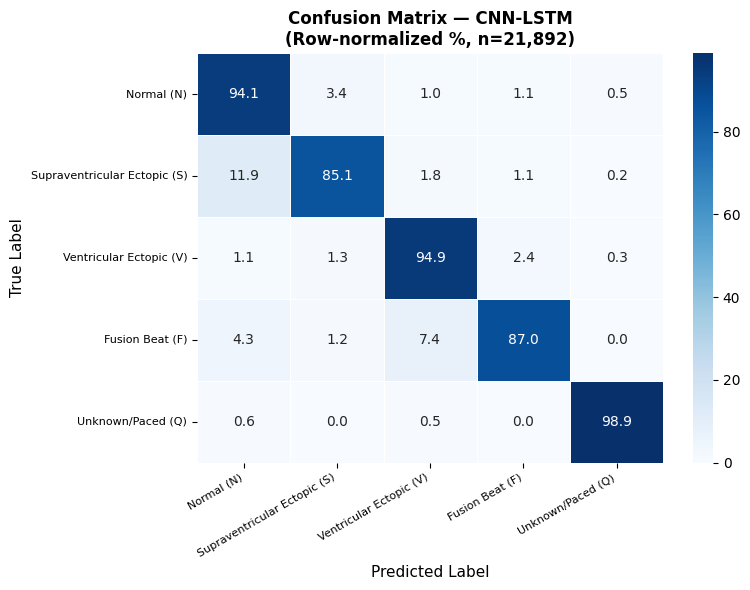

Saved: cm_cnn_lstm.png


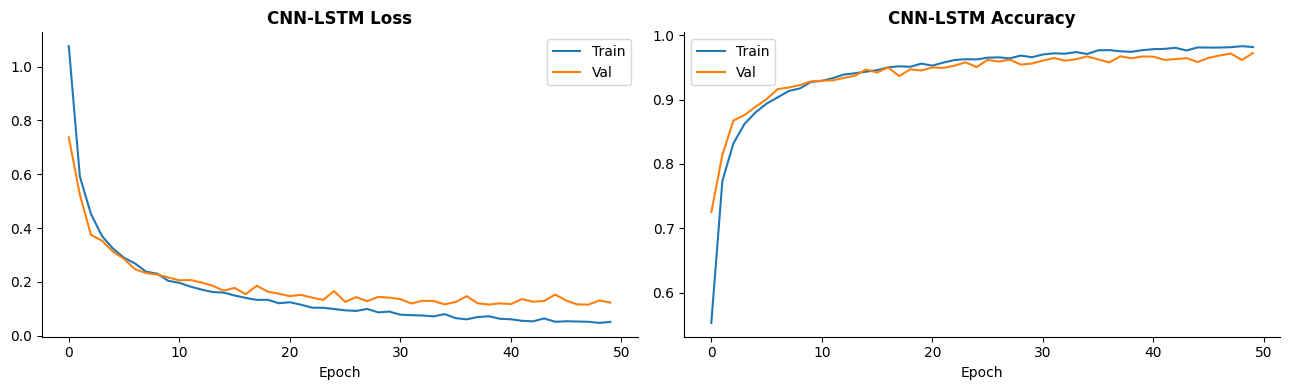

Saved: training_curves_cnn_lstm.png


In [ ]:
y_prob_lstm = cnn_lstm_model.predict(X_test_cnn)
y_pred_lstm = y_prob_lstm.argmax(axis=1)

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_f1  = f1_score(y_test, y_pred_lstm, average='macro')
lstm_auc = roc_auc_score(y_test_bin, y_prob_lstm, multi_class='ovr', average='macro')

print(f'\n=== CNN-LSTM Results ===')
print(f'Accuracy    : {lstm_acc:.4f}')
print(f'Macro F1    : {lstm_f1:.4f}')
print(f'Macro AUROC : {lstm_auc:.4f}')
print('\nPer-class Report:')
print(classification_report(y_test, y_pred_lstm, target_names=CLASS_NAMES))

plot_confusion_matrix(y_test, y_pred_lstm, 'Confusion Matrix — CNN-LSTM', 'cm_cnn_lstm.png')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_lstm.history['loss'], label='Train'); axes[0].plot(history_lstm.history['val_loss'], label='Val')
axes[0].set_title('CNN-LSTM Loss', fontweight='bold'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
axes[1].plot(history_lstm.history['accuracy'], label='Train'); axes[1].plot(history_lstm.history['val_accuracy'], label='Val')
axes[1].set_title('CNN-LSTM Accuracy', fontweight='bold'); axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('training_curves_cnn_lstm.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: training_curves_cnn_lstm.png')

## 15. Comparative Evaluation — All Models


=== Model Comparison Summary ===
        Model  Accuracy  Macro F1  Macro AUROC
Random Forest    0.8627    0.6368       0.9372
       1D CNN    0.9555    0.8223       0.9876
     CNN-LSTM    0.9420    0.7866       0.9887

Saved: model_results.json


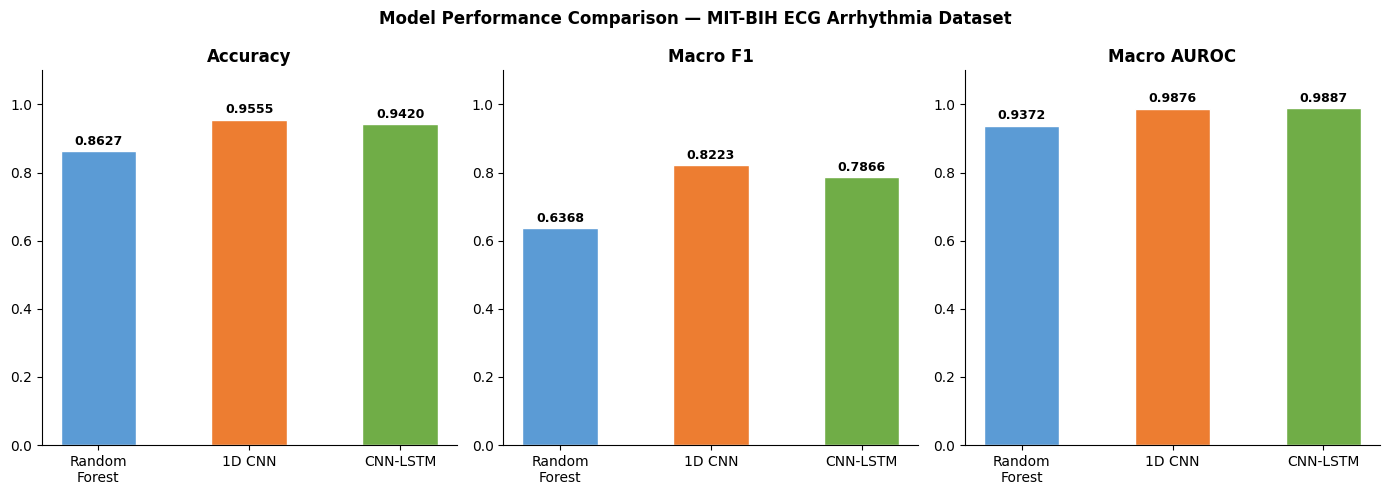

Saved: model_comparison.png


In [ ]:
# Summary table
results = pd.DataFrame({
    'Model':       ['Random Forest', '1D CNN', 'CNN-LSTM'],
    'Accuracy':    [round(rf_acc,4),  round(cnn_acc,4),  round(lstm_acc,4)],
    'Macro F1':    [round(rf_f1,4),   round(cnn_f1,4),   round(lstm_f1,4)],
    'Macro AUROC': [round(rf_auc,4),  round(cnn_auc,4),  round(lstm_auc,4)],
})
print('\n=== Model Comparison Summary ===')
print(results.to_string(index=False))
results.to_json('model_results.json', orient='records', indent=2)
print('\nSaved: model_results.json')

# Bar chart comparison
metrics = ['Accuracy', 'Macro F1', 'Macro AUROC']
colors  = ['#5B9BD5', '#ED7D31', '#70AD47']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, metric in enumerate(metrics):
    vals = results[metric].values
    bars = axes[i].bar(['Random\nForest', '1D CNN', 'CNN-LSTM'], vals,
                       color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.suptitle('Model Performance Comparison — MIT-BIH ECG Arrhythmia Dataset',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: model_comparison.png')

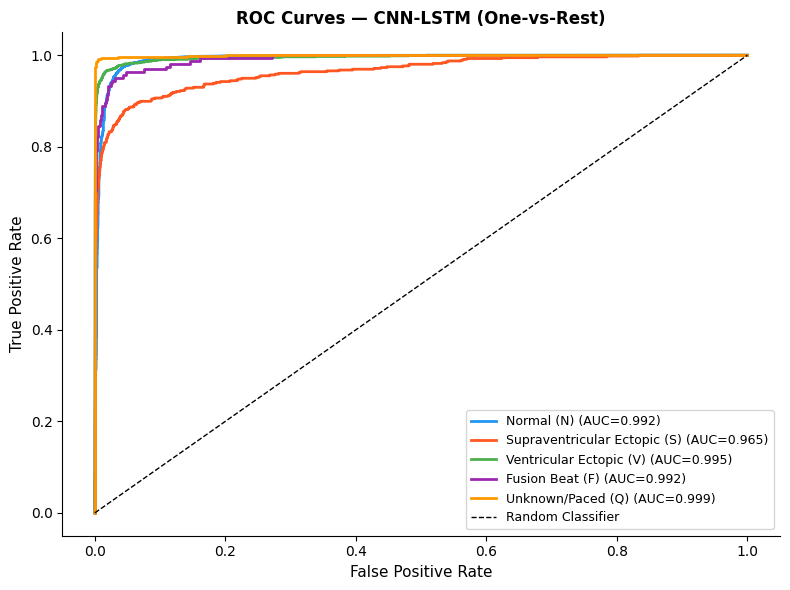

Saved: roc_curves_cnn_lstm.png


In [ ]:
# ROC Curves — CNN-LSTM (best model)
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(N_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lstm[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=CLASS_COLORS[i], linewidth=2,
            label=f'{CLASS_NAMES[i]} (AUC={roc_auc_i:.3f})')
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — CNN-LSTM (One-vs-Rest)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curves_cnn_lstm.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: roc_curves_cnn_lstm.png')